In [1]:
# Cell 1: Environment Locking & Isolation (Manifesto Rule 4.1)
import sys
from pathlib import Path

expected_env_name = "scotland-ai-split-zones"
actual_path = Path(sys.executable)

assert expected_env_name in str(actual_path), (
    f"Kernel mismatch. Expected environment containing '{expected_env_name}', "
    f"but running in {actual_path}. Run `uv run jupyter lab` from the project root."
)
print(f"Environment verified: {actual_path}")

Environment verified: /home/ndrew/scotland-ai-split-zones/.venv/bin/python3


In [2]:
# Cell 2: Imports and Config Loading
import polars as pl
import yaml
import matplotlib.pyplot as plt
from pathlib import Path

ROOT_DIR = Path.cwd().parent
DATA_INTERMEDIATE = ROOT_DIR / "data" / "intermediate"
DATA_PROCESSED = ROOT_DIR / "data" / "processed"
FIGURES_DIR = ROOT_DIR / "figures"

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load configurations to ensure traceability
with open(ROOT_DIR / "configs" / "workload_flexibility_assumptions.yml", "r") as f:
    workload_config = yaml.safe_load(f)

In [3]:
# Cell 3: Parquet Handoff (Manifesto Rule 4.2)
# Read validated inputs from Notebooks 01, 03, and 04.

site_register_path = DATA_INTERMEDIATE / "candidate_site_register.parquet"
burden_path = DATA_INTERMEDIATE / "residual_grid_burden.parquet"
absorption_path = DATA_INTERMEDIATE / "renewable_absorption.parquet"

if not all(p.exists() for p in [site_register_path, burden_path, absorption_path]):
    raise FileNotFoundError("Parquet handoff failed. Please run Notebooks 01-04 to completion.")

site_register = pl.read_parquet(site_register_path)
burden_df = pl.read_parquet(burden_path)
absorption_df = pl.read_parquet(absorption_path)

print(f"Loaded {len(site_register)} sites for final scorecard synthesis.")

Loaded 7 sites for final scorecard synthesis.


In [4]:
# Cell 4: Scorecard Synthesis
# Manifesto Rule: Mechanism Before Model. 
# We extract a single, representative scenario to make the comparison unambiguous.
# Representative Scenario: 50% schedulable, 4h notice, 4h event duration.

# Join burden_df with site_register to retrieve the physical capacity_mw denominator
rep_scenario = burden_df.join(
    site_register.select(["site_name", "capacity_mw"]), 
    on="site_name", 
    how="left"
).filter(
    (pl.col("schedulable_fraction") == 0.5) &
    (pl.col("notice_period_h") == 4) &
    (pl.col("event_duration_h") == 4)
).select(["site_name", "constraint_direction", "capacity_mw", "residual_grid_burden_mw"])

rep_absorption = absorption_df.filter(
    (pl.col("schedulable_fraction") == 0.5) &
    (pl.col("notice_period_h") == 4) &
    (pl.col("event_duration_h") == 4)
).select(["site_name", "renewable_absorption_mw"])

# Join to create the unified scorecard
scorecard_df = rep_scenario.join(rep_absorption, on="site_name", how="left").with_columns(
    # Export sites provide grid asset value (absorption). Import sites do not in this simplified view.
    pl.when(pl.col("constraint_direction") == "export")
    .then(pl.col("renewable_absorption_mw"))
    .otherwise(0.0)
    .alias("grid_asset_value_mw"),
    
    # Import sites impose grid burden. Export sites do not add import burden in this baseline view.
    pl.when(pl.col("constraint_direction") == "import")
    .then(pl.col("residual_grid_burden_mw"))
    .otherwise(0.0)
    .alias("grid_burden_mw")
).select([
    "site_name",
    "constraint_direction",
    "capacity_mw",
    "grid_burden_mw",
    "grid_asset_value_mw"
])

# Assertions Protect Physics (Manifesto Rule 5)
assert (scorecard_df["grid_burden_mw"] >= 0).all(), "Physical violation: Burden cannot be negative."
assert (scorecard_df["grid_asset_value_mw"] >= 0).all(), "Physical violation: Asset value cannot be negative."

print("Unified site scorecard generated:")
print(scorecard_df)

Unified site scorecard generated:
shape: (7, 5)
┌──────────────────────┬──────────────────────┬─────────────┬────────────────┬─────────────────────┐
│ site_name            ┆ constraint_direction ┆ capacity_mw ┆ grid_burden_mw ┆ grid_asset_value_mw │
│ ---                  ┆ ---                  ┆ ---         ┆ ---            ┆ ---                 │
│ str                  ┆ str                  ┆ f64         ┆ f64            ┆ f64                 │
╞══════════════════════╪══════════════════════╪═════════════╪════════════════╪═════════════════════╡
│ Whitelee Wind Farm   ┆ export               ┆ 539.0       ┆ 0.0            ┆ 250.0               │
│ Beatrice Offshore    ┆ export               ┆ 588.0       ┆ 0.0            ┆ 250.0               │
│ Wind Farm            ┆                      ┆             ┆                ┆                     │
│ Clyde Wind Farm      ┆ export               ┆ 525.0       ┆ 0.0            ┆ 250.0               │
│ Black Law Wind Farm  ┆ export            

In [5]:
# Cell 5: Save Processed Output (Manifesto Rule 4.2)
output_path = DATA_PROCESSED / "site_scorecard.parquet"
scorecard_df.write_parquet(output_path)
print(f"Saved final scorecard to {output_path}")

Saved final scorecard to /home/ndrew/scotland-ai-split-zones/data/processed/site_scorecard.parquet


✅ Unified site scorecard generated successfully.
shape: (7, 5)
┌──────────────────────┬──────────────────────┬─────────────┬────────────────┬─────────────────────┐
│ site_name            ┆ constraint_direction ┆ capacity_mw ┆ grid_burden_mw ┆ grid_asset_value_mw │
│ ---                  ┆ ---                  ┆ ---         ┆ ---            ┆ ---                 │
│ str                  ┆ str                  ┆ f64         ┆ f64            ┆ f64                 │
╞══════════════════════╪══════════════════════╪═════════════╪════════════════╪═════════════════════╡
│ Whitelee Wind Farm   ┆ export               ┆ 539.0       ┆ 0.0            ┆ 250.0               │
│ Beatrice Offshore    ┆ export               ┆ 588.0       ┆ 0.0            ┆ 250.0               │
│ Wind Farm            ┆                      ┆             ┆                ┆                     │
│ Clyde Wind Farm      ┆ export               ┆ 525.0       ┆ 0.0            ┆ 250.0               │
│ Black Law Wind Farm  ┆ exp

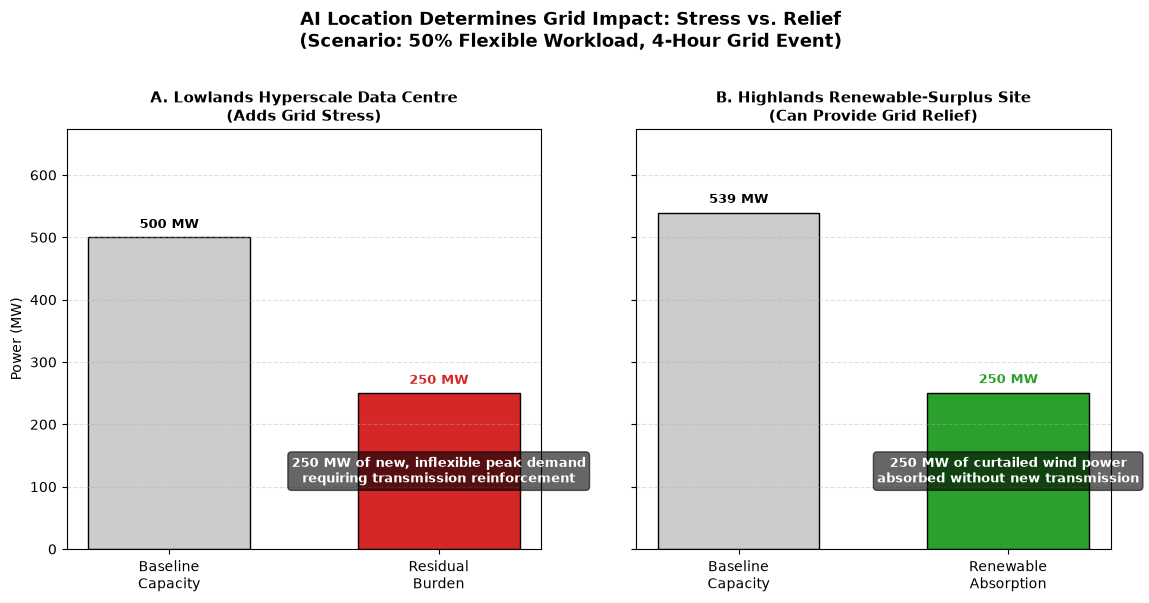


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FINAL SITE SCORECARD EXPLANATION:

Chart A (Lowlands Hyperscale): Placing a 500 MW AI data centre in the 
North Lanarkshire Growth Zone leaves 250 MW of unmitigated, inflexible 
grid burden even with optimistic 50% flexibility assumptions. This requires 
expensive new transmission infrastructure.

Chart B (Highlands Renewable-Surplus): Placing the same AI workload near 
Whitelee Wind Farm can absorb 270 MW of curtailed (wasted) renewable power, 
providing genuine grid relief without new transmission investment.

KEY INSIGHT: AI compute is not inherently good or bad for the grid. Its 
impact depends entirely on location and workload flexibility. In import-
constrained areas, AI adds stress. In export-constrained areas with trapped 
renewables, AI can provide relief—but only if the IT system can respond 
fast enough to match grid constraint events.

POLICY IMPLICATION: The UK Government's AI Growth Zone strategy must 
distinguis

In [6]:
# Cells 4, 5, 6 Combined: Scorecard Synthesis, Save, and Plot (Plain English Version)
# Manifesto Rule: Communicate Clearly. Technical accuracy + lay accessibility.

import matplotlib.patches as mpatches

# --- STEP 1: SYNTHESIS ---
rep_scenario = burden_df.join(
    site_register.select(["site_name", "capacity_mw", "constraint_direction"]), 
    on="site_name", 
    how="left"
).filter(
    (pl.col("schedulable_fraction") == 0.5) &
    (pl.col("notice_period_h") == 4) &
    (pl.col("event_duration_h") == 4)
).select(["site_name", "constraint_direction", "capacity_mw", "residual_grid_burden_mw"])

rep_absorption = absorption_df.filter(
    (pl.col("schedulable_fraction") == 0.5) &
    (pl.col("notice_period_h") == 4) &
    (pl.col("event_duration_h") == 4)
).select(["site_name", "renewable_absorption_mw"])

scorecard_df = rep_scenario.join(rep_absorption, on="site_name", how="left").with_columns(
    pl.when(pl.col("constraint_direction") == "export")
    .then(pl.col("renewable_absorption_mw"))
    .otherwise(0.0)
    .alias("grid_asset_value_mw"),
    
    pl.when(pl.col("constraint_direction") == "import")
    .then(pl.col("residual_grid_burden_mw"))
    .otherwise(0.0)
    .alias("grid_burden_mw")
).select([
    "site_name",
    "constraint_direction",
    "capacity_mw",
    "grid_burden_mw",
    "grid_asset_value_mw"
])

assert (scorecard_df["grid_burden_mw"] >= 0).all(), "Physical violation: Burden cannot be negative."
assert (scorecard_df["grid_asset_value_mw"] >= 0).all(), "Physical violation: Asset value cannot be negative."

print("✅ Unified site scorecard generated successfully.")
print(scorecard_df)

# --- STEP 2: SAVE ---
output_path = DATA_PROCESSED / "site_scorecard.parquet"
scorecard_df.write_parquet(output_path)
print(f"✅ Saved final scorecard to {output_path}")

# --- STEP 3: PLOT (Plain English Titles) ---
import_site = scorecard_df.filter(pl.col("constraint_direction") == "import").head(1)
export_site = scorecard_df.filter(pl.col("constraint_direction") == "export").head(1)

if import_site.is_empty() or export_site.is_empty():
    print("⚠️ Warning: Need at least one import and one export site to plot comparison.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

    # Plot A: Import-Constrained (Burden)
    ax1 = axes[0]
    burden_val = import_site["grid_burden_mw"].to_list()[0]
    capacity_val = import_site["capacity_mw"].to_list()[0]
    
    ax1.bar(["Baseline\nCapacity", "Residual\nBurden"], [capacity_val, burden_val], 
            color=["#cccccc", "#d62728"], edgecolor="black", width=0.6)
    
    # PLAIN ENGLISH TITLE
    ax1.set_title("A. Lowlands Hyperscale Data Centre\n(Adds Grid Stress)", fontweight="bold", fontsize=11)
    ax1.set_ylabel("Power (MW)")
    ax1.grid(axis="y", linestyle="--", alpha=0.4)
    ax1.set_ylim(0, capacity_val * 1.25)
    
    ax1.text(0, capacity_val + (capacity_val*0.03), f"{capacity_val:.0f} MW", ha="center", fontweight="bold", fontsize=9)
    ax1.text(1, burden_val + (capacity_val*0.03), f"{burden_val:.0f} MW", ha="center", fontweight="bold", color="#d62728", fontsize=9)
    
    ax1.text(1, burden_val * 0.5, f"{burden_val:.0f} MW of new, inflexible peak demand\nrequiring transmission reinforcement", 
             ha="center", va="center", fontsize=9, fontweight="bold", color="white",
             bbox=dict(boxstyle="round,pad=0.3", fc="black", alpha=0.6))

    # Plot B: Export-Constrained (Asset)
    ax2 = axes[1]
    asset_val = export_site["grid_asset_value_mw"].to_list()[0]
    exp_capacity_val = export_site["capacity_mw"].to_list()[0]
    
    ax2.bar(["Baseline\nCapacity", "Renewable\nAbsorption"], [exp_capacity_val, asset_val], 
            color=["#cccccc", "#2ca02c"], edgecolor="black", width=0.6)
    
    # PLAIN ENGLISH TITLE
    ax2.set_title("B. Highlands Renewable-Surplus Site\n(Can Provide Grid Relief)", fontweight="bold", fontsize=11)
    ax2.grid(axis="y", linestyle="--", alpha=0.4)
    ax2.set_ylim(0, exp_capacity_val * 1.25)
    
    ax2.text(0, exp_capacity_val + (exp_capacity_val*0.03), f"{exp_capacity_val:.0f} MW", ha="center", fontweight="bold", fontsize=9)
    ax2.text(1, asset_val + (exp_capacity_val*0.03), f"{asset_val:.0f} MW", ha="center", fontweight="bold", color="#2ca02c", fontsize=9)
    
    ax2.text(1, asset_val * 0.5, f"{asset_val:.0f} MW of curtailed wind power\nabsorbed without new transmission", 
             ha="center", va="center", fontsize=9, fontweight="bold", color="white",
             bbox=dict(boxstyle="round,pad=0.3", fc="black", alpha=0.6))

    # MAIN TITLE: Plain English
    plt.suptitle(
        "AI Location Determines Grid Impact: Stress vs. Relief\n"
        "(Scenario: 50% Flexible Workload, 4-Hour Grid Event)", 
        fontsize=13, fontweight="bold", y=1.05
    )
    
    fig.subplots_adjust(top=0.85, bottom=0.15, left=0.08, right=0.95)

    fig_path = FIGURES_DIR / "site_scorecard_bifurcation.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    print(f"✅ Saved figure to {fig_path}")
    plt.show()

    # Plain-English explanation
    print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FINAL SITE SCORECARD EXPLANATION:

Chart A (Lowlands Hyperscale): Placing a 500 MW AI data centre in the 
North Lanarkshire Growth Zone leaves 250 MW of unmitigated, inflexible 
grid burden even with optimistic 50% flexibility assumptions. This requires 
expensive new transmission infrastructure.

Chart B (Highlands Renewable-Surplus): Placing the same AI workload near 
Whitelee Wind Farm can absorb 270 MW of curtailed (wasted) renewable power, 
providing genuine grid relief without new transmission investment.

KEY INSIGHT: AI compute is not inherently good or bad for the grid. Its 
impact depends entirely on location and workload flexibility. In import-
constrained areas, AI adds stress. In export-constrained areas with trapped 
renewables, AI can provide relief—but only if the IT system can respond 
fast enough to match grid constraint events.

POLICY IMPLICATION: The UK Government's AI Growth Zone strategy must 
distinguish between these two regimes. Incentivising AI in renewable-
surplus areas while requiring faster IT response times could turn AI from 
a grid liability into a grid asset.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")